In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

In [2]:
def extract_features(digit_row):
    intensity = np.sum((digit_row + 1)/2)/256
    digit_row = digit_row[1:257]
    digit_row = digit_row.reshape(16, 16)
    flipped_hor = np.flip(digit_row, 1)
    flipped_ver = np.flip(digit_row, 0)
    hor_symmetry = np.sum(np.multiply(digit_row, flipped_hor))/256
    ver_symmetry = np.sum(np.multiply(digit_row, flipped_ver))/256
    symmetry = (hor_symmetry + ver_symmetry)/2
    return intensity, symmetry


In [3]:
def plot_features(X, y):
    colors = []
    for y_col in y:
        if y_col == 1:
            colors.append('b')
        else:
            colors.append('r')
    plt.scatter(X[:,0], X[:,1], color=colors)

def abline(slope, intercept):
    """Plot a line from slope and intercept"""
    axes = plt.gca()
    x_vals = np.array(axes.get_xlim())
    y_vals = intercept + slope * x_vals
    plt.plot(x_vals, y_vals, '--', label = "x_2="+str(slope)+"x_1+"+str(intercept) )


In [4]:
train_digits = []
with open('/content/ZipDigits.train') as fp:
    for line in fp:
      train_digits.append([float(x) for x in line.split()])

train_digits = np.array(train_digits)

In [5]:
digit1 = 1
digit2 = 5
train_digits = train_digits[(train_digits[:,0] == digit1) | (train_digits[:,0] == digit2)]

In [6]:
X = []
y = []
for row in train_digits:
    intensity, symmetry = extract_features(row)
    X.append([intensity, symmetry])
    if row[0] == digit1:
        y.append(1)
    else:
        y.append(-1)

X = np.array(X)
y = np.array(y)


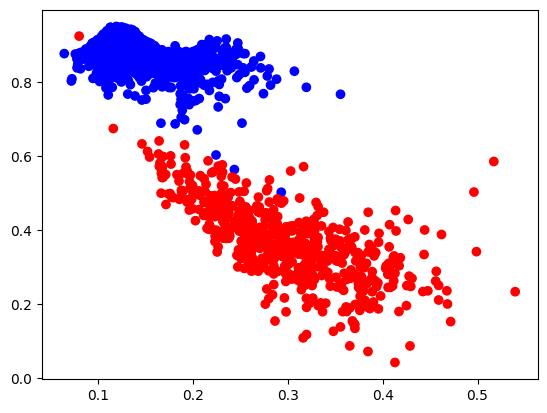

In [7]:
plot_features(X, y)

In [8]:
import pandas as pd
df = pd.DataFrame(X, columns=["x1", "x2"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1561 entries, 0 to 1560
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      1561 non-null   float64
 1   x2      1561 non-null   float64
dtypes: float64(2)
memory usage: 24.5 KB


In [10]:
df['y'] = y

In [12]:
df.to_csv('zip_digits_features', index=False)

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X,y)

LogisticRegression()

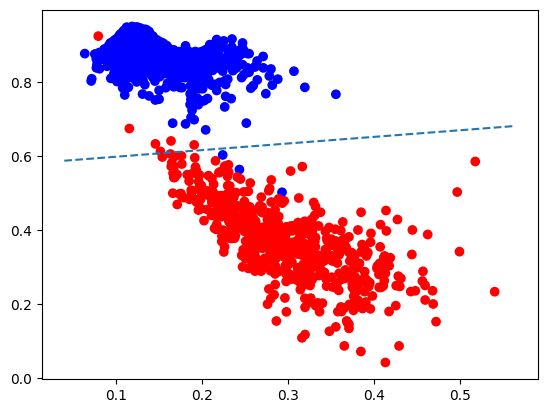

In [ ]:
plot_features(X, y)
abline(-lr.coef_[0,0]/lr.coef_[0,1], -lr.intercept_[0]/lr.coef_[0,1])

In [ ]:
X_train = X
y_train = y

In [ ]:
from sklearn.neural_network import MLPClassifier
nn_clf = MLPClassifier(solver='adam', hidden_layer_sizes=(10,10),early_stopping=True)
nn_clf.fit(X_train, y_train)
nn_clf.validation_scores_

[0.35668789808917195,
 0.8280254777070064,
 0.643312101910828,
 0.643312101910828,
 0.643312101910828,
 0.643312101910828,
 0.643312101910828,
 0.643312101910828,
 0.643312101910828,
 0.643312101910828,
 0.643312101910828,
 0.643312101910828,
 0.643312101910828]

In [ ]:
#Plot boundary

# number of data points
n = 1000
# x, y
x1 = np.linspace(0, 1, n)
x2 = np.linspace(0, 1, n)

# meshgrid
XM1, XM2 = np.meshgrid(x1, x2)


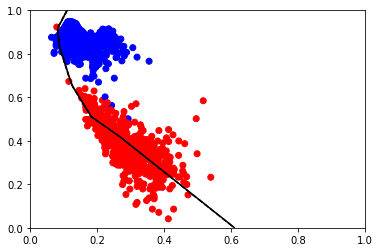

In [ ]:
plot_features(X_train, y_train)
Z = nn_clf.predict(np.c_[XM1.ravel(), XM2.ravel()])
Z = Z.reshape(XM1.shape)
plt.contour(XM1, XM2, Z, 1, colors = 'black')


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix

nn_clf = MLPClassifier(max_iter=100,solver='adam',early_stopping=True,random_state=10)
hidden_layer_sizes=[(4,4), (6,6), (12,12), (4,4,4), (6,6,6)]
grid = dict(hidden_layer_sizes=hidden_layer_sizes)
clf = GridSearchCV(estimator=nn_clf, param_grid=grid, cv=5)
best_model = clf.fit(X_train, y_train)

best_score, best_params = best_model.best_score_, best_model.best_params_
print("Best score is: ", best_score)
print("Best parameters are: ", best_params)

y_pred = best_model.predict(X_train)
print("Accuracy: ", best_model.score(X_train, y_train))
print("Confusion Matrix: ")
confusion_matrix(y_train, y_pred)

Best score is:  0.6438191201769476
Best parameters are:  {'hidden_layer_sizes': (6, 6)}
Accuracy:  0.643818065342729
Confusion Matrix: 


array([[   0,  556],
       [   0, 1005]])

# Decision Trees

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier(criterion="gini",min_samples_split=4,max_depth=3)
dt_clf.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=3, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=4,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=None, splitter='best')

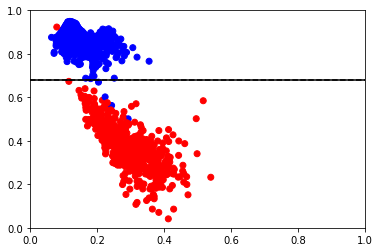

In [ ]:
plot_features(X_train, y_train)
Z = dt_clf.predict(np.c_[XM1.ravel(), XM2.ravel()])
Z = Z.reshape(XM1.shape)
plt.contour(XM1, XM2, Z, 1, colors = 'black')

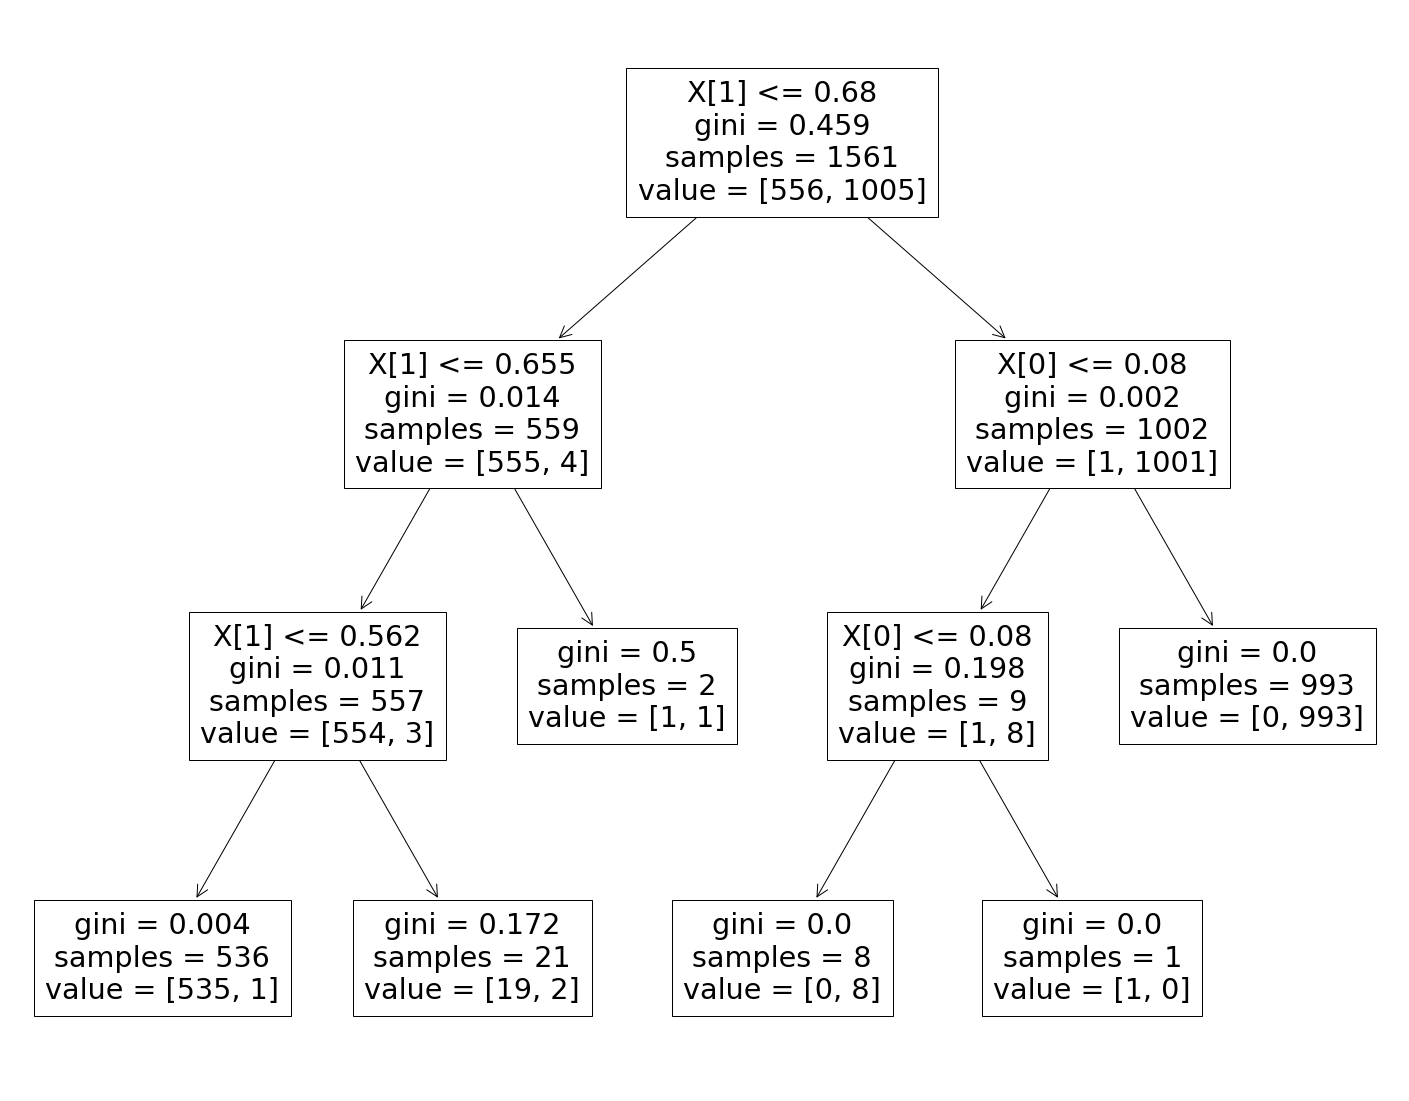

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(25,20))
fig = tree.plot_tree(dt_clf)

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(n_estimators=20, criterion='entropy')
rf_clf.fit(X_train, y_train)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='entropy', max_depth=None, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=20,
                       n_jobs=None, oob_score=False, random_state=None,
                       verbose=0, warm_start=False)

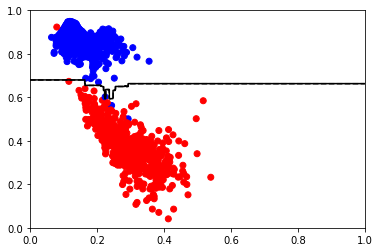

In [ ]:
plot_features(X_train, y_train)
Z = rf_clf.predict(np.c_[XM1.ravel(), XM2.ravel()])
Z = Z.reshape(XM1.shape)
plt.contour(XM1, XM2, Z, 1, colors = 'black')

Support Vector Machines

In [ ]:
from sklearn.svm import SVC
svm_clf = SVC(gamma="auto", kernel="rbf")
svm_clf.fit(X_train, y_train)

SVC(gamma='auto')

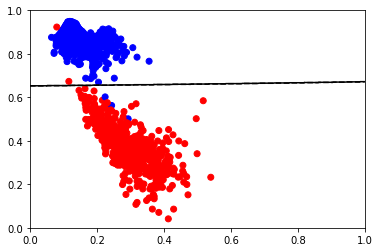

In [ ]:
plot_features(X_train, y_train)
Z = svm_clf.predict(np.c_[XM1.ravel(), XM2.ravel()])
Z = Z.reshape(XM1.shape)
plt.contour(XM1, XM2, Z, 1, colors = 'black')

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix

svm_clf = SVC(gamma="auto")
kernel=["linear", "rbf", "poly"]
C=[0.1, 1, 10]
grid = dict(kernel=kernel, C=C)
clf = GridSearchCV(estimator=svm_clf, param_grid=grid, cv=5)
best_model = clf.fit(X_train, y_train)

best_score, best_params = best_model.best_score_, best_model.best_params_
print("Best score is: ", best_score)
print("Best parameters are: ", best_params)

y_pred = best_model.predict(X_train)
print("Accuracy: ", best_model.score(X_train, y_train))
print("Confusion Matrix: ")
confusion_matrix(y_train, y_pred)

Best score is:  0.9967969198001146
Best parameters are:  {'C': 1, 'kernel': 'linear'}
Accuracy:  0.9967969250480462
Confusion Matrix: 


array([[ 554,    2],
       [   3, 1002]])